# Chapter 4 : Neural Network (ANN)
**Dataset :** cs-training-clean.csv

## Step 1 : Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

print("✅ Libraries imported!")

✅ Libraries imported!


## Step 2 : Load the Clean Dataset

In [2]:
df = pd.read_csv("cs-training-clean.csv")
print(f"Dataset loaded — {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded — 109536 rows x 12 columns


,Serious_Dlq_In_2Yrs,Revolving_Utilization_Of_Unsecured_Lines,Age,Number_Of_Time_30_59_Days_Past_Due,Debt_Ratio,Monthly_Income,Number_Of_Open_Credit_Lines_And_Loans,Number_Of_Times_90_Days_Late,Number_Real_Estate_Loans_Or_Lines,Number_Of_Time_60_89_Days_Past_Due,Number_Of_Dependents,Debt_To_Income_Ratio
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,7323.197016
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,316.878123
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,258.914887
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,118.963951
4,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0,1314.624392


## Step 3 : Prepare X (features) and y (target)

In [3]:
# X = all columns except the target
# y = the target column (1 = default, 0 = no default)
X = df.drop(columns=["Serious_Dlq_In_2Yrs"])
y = df["Serious_Dlq_In_2Yrs"]

# split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} rows | Test : {X_test.shape[0]} rows")

Train : 87628 rows | Test : 21908 rows


## Step 4 : Fix Class Imbalance with SMOTE

In [4]:
# SMOTE creates fake but realistic examples of the minority class (defaulters)
# applied ONLY on training data — never on test data!
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")
print(f"After  SMOTE — Class 0: {(y_train_bal==0).sum()} | Class 1: {(y_train_bal==1).sum()}")

Before SMOTE — Class 0: 81460 | Class 1: 6168
After  SMOTE — Class 0: 81460 | Class 1: 81460


## Step 5 : Scale the Data

In [5]:
# Neural Networks require scaled data to train properly
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)
print("✅ Data scaled!")

✅ Data scaled!


## Step 6 : Convert to PyTorch Tensors

In [6]:
# PyTorch works with Tensors not numpy arrays
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

X_train_t = torch.tensor(X_train_scaled,     dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_bal.values, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_scaled,      dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test.values,      dtype=torch.float32).to(device)

# DataLoader splits data into batches during training
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=512, shuffle=True)
print("✅ Tensors ready!")

Running on: cpu
✅ Tensors ready!


## Step 7 : Build the Neural Network

Architecture:
```
Input (12 features)
  → Layer 1 : 64 neurons + ReLU + Dropout(30%)
  → Layer 2 : 32 neurons + ReLU + Dropout(20%)
  → Layer 3 : 16 neurons + ReLU
  → Output  : 1 neuron  + Sigmoid → probability
```

In [7]:
class CreditNet(nn.Module):
    def __init__(self, n_features):
        super(CreditNet, self).__init__()
        self.network = nn.Sequential(
            # Layer 1 : 64 neurons
            # ReLU removes negative values to help learning
            # Dropout turns off 30% of neurons to avoid overfitting
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2 : 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 3 : 16 neurons
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output : 1 neuron
            # Sigmoid gives output between 0 and 1 (probability)
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


n_features = X_train_scaled.shape[1]
model_nn   = CreditNet(n_features).to(device)

total_params = sum(p.numel() for p in model_nn.parameters())
print(f"✅ Neural Network created!")
print(f"   Input features   : {n_features}")
print(f"   Total parameters : {total_params:,}")

✅ Neural Network created!
   Input features   : 11
   Total parameters : 3,393


## Step 8 : Train the Neural Network

In [8]:
# Loss function : measures how wrong the model is
criterion = nn.BCELoss()

# Optimizer : updates weights to reduce the loss
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

# Training loop
history      = {"train_loss": [], "val_loss": []}
best_auc     = 0.0
best_state   = None
patience     = 10
no_improve   = 0
y_test_np    = y_test.values

print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Val AUC':>8}")
print("-" * 35)

for epoch in range(1, 61):

    # --- Training ---
    model_nn.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_nn(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
    train_loss = total_loss / len(train_loader.dataset)

    # --- Validation ---
    model_nn.eval()
    with torch.no_grad():
        val_probs = model_nn(X_test_t).cpu().numpy()
    val_auc = roc_auc_score(y_test_np, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_auc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>11.4f} | {val_auc:>8.4f}")

    # --- Early stopping ---
    if val_auc > best_auc:
        best_auc   = val_auc
        best_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model_nn.load_state_dict(best_state)
print(f"\n✅ Training complete! Best AUC-ROC: {best_auc:.4f}")

 Epoch |  Train Loss |  Val AUC
-----------------------------------
     1 |      0.5440 |   0.7906
    10 |      0.4463 |   0.8217
    20 |      0.4041 |   0.8277

Early stopping at epoch 29

✅ Training complete! Best AUC-ROC: 0.8285


## Step 9 : Training Curves

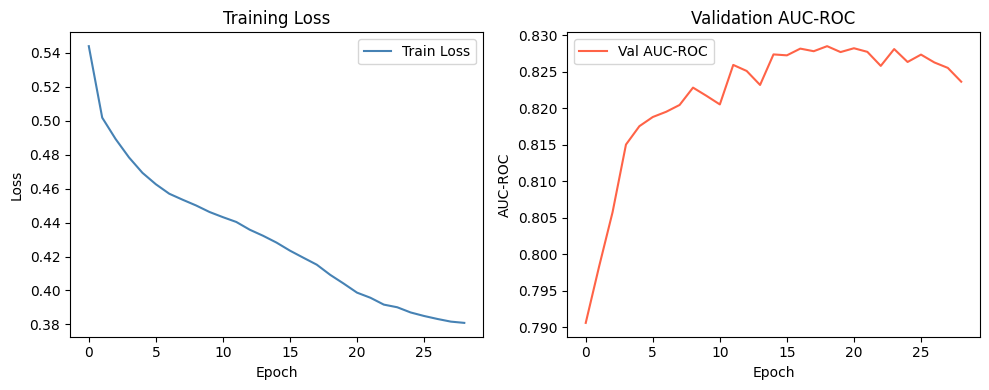

✅ Saved: nn_training_curves.png


In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], color="steelblue", label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_loss"], color="tomato", label="Val AUC-ROC")
plt.title("Validation AUC-ROC")
plt.xlabel("Epoch")
plt.ylabel("AUC-ROC")
plt.legend()

plt.tight_layout()
plt.savefig("nn_training_curves.png")
plt.show()
print("✅ Saved: nn_training_curves.png")

## Step 10 : Evaluate the Neural Network

  NEURAL NETWORK - RESULTS
  Accuracy  : 79.0%
  Recall    : 69.91%  ← most important
  Precision : 20.68%
  AUC-ROC   : 0.8285


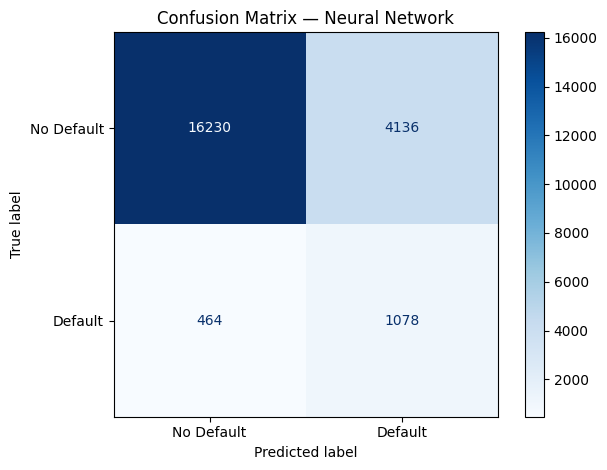

In [10]:
model_nn.eval()
with torch.no_grad():
    y_prob_nn = model_nn(X_test_t).cpu().numpy()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

accuracy  = round(accuracy_score (y_test_np, y_pred_nn) * 100, 2)
recall    = round(recall_score   (y_test_np, y_pred_nn) * 100, 2)
precision = round(precision_score(y_test_np, y_pred_nn) * 100, 2)
auc_roc   = round(roc_auc_score  (y_test_np, y_prob_nn), 4)

print("=" * 45)
print("  NEURAL NETWORK - RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy}%")
print(f"  Recall    : {recall}%  ← most important")
print(f"  Precision : {precision}%")
print(f"  AUC-ROC   : {auc_roc}")
print("=" * 45)

# Confusion matrix
cm   = confusion_matrix(y_test_np, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Neural Network")
plt.tight_layout()
plt.savefig("nn_confusion_matrix.png")
plt.show()

## Step 11 : Loan Decision Function (4 Outputs)

In [11]:
def loan_decision_nn(client):

    client_df     = pd.DataFrame([client])
    client_scaled = scaler.transform(client_df)
    client_tensor = torch.tensor(client_scaled, dtype=torch.float32).to(device)

    model_nn.eval()
    with torch.no_grad():
        prob = model_nn(client_tensor).item() * 100

    # risk level
    if prob < 30:
        risk = "Low Risk"
    elif prob < 60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    # decision
    decision = "Approved" if prob < 30 else "Rejected"

    # loan amount
    if decision == "Approved":
        loan_amount = client["Monthly_Income"] * 3
        loan_amount = loan_amount - (client["Debt_Ratio"] * client["Monthly_Income"])
        loan_amount = max(0, round(loan_amount, 2))
    else:
        loan_amount = 0

    print("-" * 35)
    print(f" Default Probability : {prob:.1f}%")
    print(f" Risk Level          : {risk}")
    print(f" Decision            : {decision}")
    print(f" Loan Amount         : ${loan_amount:,.0f}")
    print("-" * 35)

print("✅ loan_decision_nn function ready!")

✅ loan_decision_nn function ready!


## Step 12 : Test with Approved Clients

In [12]:
feature_cols = X.columns.tolist()
approved = 0

for i in range(len(X_test)):
    client = {col: X_test.iloc[i][col] for col in feature_cols}
    client_df     = pd.DataFrame([client])
    client_scaled = scaler.transform(client_df)
    client_tensor = torch.tensor(client_scaled, dtype=torch.float32).to(device)
    model_nn.eval()
    with torch.no_grad():
        prob = model_nn(client_tensor).item() * 100
    if prob < 30:
        print(f"Client {approved+1}:")
        loan_decision_nn(client)
        approved += 1
    if approved == 3:
        break

print("\n🎉 Chapter 4 (Neural Network) Complete!")

Client 1:
-----------------------------------
 Default Probability : 14.6%
 Risk Level          : Low Risk
 Decision            : Approved
 Loan Amount         : $14,959
-----------------------------------
Client 2:
-----------------------------------
 Default Probability : 28.6%
 Risk Level          : Low Risk
 Decision            : Approved
 Loan Amount         : $25,176
-----------------------------------
Client 3:
-----------------------------------
 Default Probability : 7.3%
 Risk Level          : Low Risk
 Decision            : Approved
 Loan Amount         : $11,944
-----------------------------------

🎉 Chapter 4 (Neural Network) Complete!
